<a href="https://colab.research.google.com/github/ameliagarciarond22-source/Modelos-Estoc-sticos-/blob/main/Algoritmo_para_simular_una_Cadena_de_Markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##SIMULACIÓN: Tablero de colores

El problema consiste en un tablero con cuatro sectores. En cada paso se lanzan dos monedas y el número de caras determina cuántos sectores se avanza en sentido horario. Debido a las probabilidades del lanzamiento de las monedas, se define una matriz de transición que describe las probabilidades de pasar de un sector a otro.

In [5]:

# LIBRERIAS

import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ENTRADA: alpha, P, n

# Matriz de transición (puede modificarse para otros ejemplos)
P = sp.Matrix([
[1/4, 1/2, 1/4, 0],
[0, 1/4, 1/2, 1/4],
[1/4, 0, 1/4, 1/2],
[1/2, 1/4, 0, 1/4]
])

# Distribución inicial α
alpha = np.array([0.25,0.25,0.25,0.25])

# número de pasos
n = 10000

# GENERAR λ0 DE ACUERDO A α

estados = list(range(len(alpha)))

X0 = int(np.random.choice(estados,p=alpha))

trayectoria = [X0]

print("X0 =",X0)


# PARA i = 1,2,...,n

for i in range(1,n+1):

    # si Xi-1 = j
    j = trayectoria[i-1]

    # tomar p = renglón j de P
    p = np.array(P.row(j)).astype(float)[0]

    # generar Xi relacionado con P
    Xi = int(np.random.choice(estados,p=p))

    trayectoria.append(Xi)


# SALIDA: X0,X1,...,Xn

print("\nPrimeros estados de la cadena:")
print(" → ".join(map(str,trayectoria[:20])))


# VERIFICAR PROBABILIDADES A LARGO PLAZO

conteo = np.zeros(len(estados))

for estado in trayectoria:
    conteo[estado] += 1

frecuencia = conteo/len(trayectoria)

print("\nFrecuencia empírica:")
for i in range(len(estados)):
    print("Estado",i,":",frecuencia[i])

X0 = 0

Primeros estados de la cadena:
0 → 2 → 0 → 0 → 1 → 1 → 2 → 0 → 1 → 2 → 0 → 0 → 1 → 3 → 0 → 1 → 3 → 1 → 2 → 3

Frecuencia empírica:
Estado 0 : 0.2542745725427457
Estado 1 : 0.24827517248275172
Estado 2 : 0.24537546245375463
Estado 3 : 0.25207479252074794


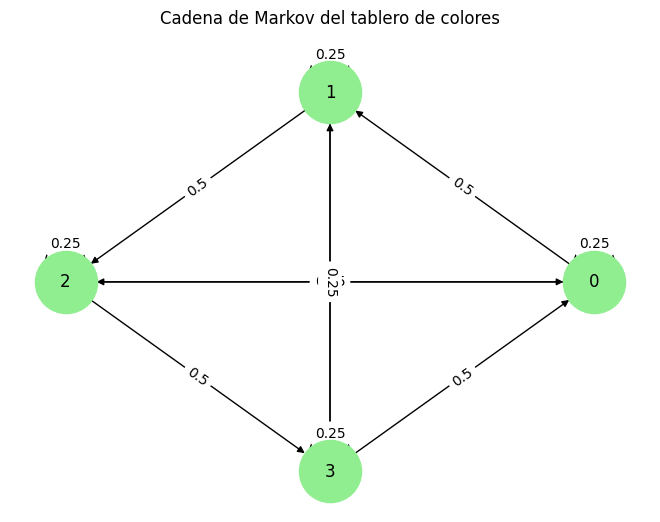

In [6]:

G = nx.DiGraph()

# agregar nodos
for i in estados:
    G.add_node(i)

# agregar aristas con probabilidades
for i in range(P.rows):
    for j in range(P.cols):
        if P[i,j] != 0:
            G.add_edge(i,j,weight=float(P[i,j]))

pos = nx.circular_layout(G)

nx.draw(G,pos,with_labels=True,node_color="lightgreen",node_size=2000)

labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.title("Cadena de Markov del tablero de colores")
plt.show()

##Conclusión
A partir de la simulación de la cadena de Markov se obtuvo una secuencia de estados que permite observar el comportamiento del sistema después de muchos pasos. En el programa se utilizó n=10000 iteraciones para que las frecuencias observadas se estabilicen y se aproximen a las probabilidades teóricas.
Los resultados muestran que, a largo plazo, cada uno de los cuatro sectores del tablero aparece aproximadamente con probabilidad 0.25. Esto indica que el proceso tiende a una distribución uniforme, lo cual coincide con lo esperado para este modelo.